# Image EDA — Dữ liệu ảnh đánh giá sản phẩm

Notebook này phân tích tập ảnh đã được gán nhãn thu thập từ các đánh giá sản phẩm thương mại điện tử. Phần 1 khảo sát đặc trưng thống kê cơ bản của tập dữ liệu. Phần 2 thử nghiệm sơ bộ tác động của các kỹ thuật tiền xử lý ảnh phổ biến thông qua kNN.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import image_eda_utils as utils

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

## 1. Configuration & Initialization
Thiết lập các biến môi trường và thư mục lưu trữ kết quả đầu ra (artifacts).

In [2]:
PROJECT_ROOT = '..'
LABELED_DIR = os.path.join(PROJECT_ROOT, 'image_labeling', 'data', 'labeled')
OUTPUT_DIR = 'outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_SIZE = 800
RANDOM_SEED = 42
WORKING_SIZE = (128, 128)
KNN_K = 5

Dữ liệu ảnh được lưu trong thư mục `image_labeling/data/labeled/` với 4 lớp con: `intact`, `irrelevant`, `damaged`, `wrong_item`. `SAMPLE_SIZE = 800` là giới hạn mẫu cho các tác vụ nặng (resize hàng loạt, augmentation), trong khi pHash và đếm lớp chạy trên toàn bộ tập.


## 2. Load Data
Quét toàn bộ thư mục `labeled/` để lấy danh sách ảnh và nhãn tương ứng. Do một số bước xử lý tốn nhiều tài nguyên, chỉ một tập con được lấy mẫu phân tầng theo nhãn để đảm bảo mỗi lớp đều có đại diện.

In [3]:
df_all = utils.load_image_paths_and_labels(LABELED_DIR)
print(f"Total images found: {len(df_all)}")

df_sampled = utils.stratified_sample(df_all, SAMPLE_SIZE, RANDOM_SEED, stratified=True)
print(f"Sampled images for heavy processing: {len(df_sampled)}")

if len(df_sampled) > 0:
    images, labels = utils.load_images(df_sampled, target_size=WORKING_SIZE)
else:
    images, labels = np.array([]), np.array([])
    print("No images to load. Ensure LABELED_DIR is correctly populated.")

Total images found: 7987
Sampled images for heavy processing: 518


Loading Images: 100%|██████████| 518/518 [00:06<00:00, 77.19it/s] 


Tổng cộng tìm thấy **7.987 ảnh**. Do lớp `damaged` chỉ có 101 mẫu và `wrong_item` chỉ có 17 mẫu, stratified sampling chỉ lấy được **518 ảnh** (giới hạn bởi lớp nhỏ nhất) thay vì 800 như cài đặt. Tập 518 ảnh này được dùng cho các phân tích nặng (phần 2), còn phân tích đếm lớp và pHash chạy trên toàn bộ 7.987 ảnh.

### Xem mẫu ảnh từng lớp

Xem một vài ảnh đại diện để hiểu trực quan về nội dung từng nhãn trước khi phân tích định lượng.


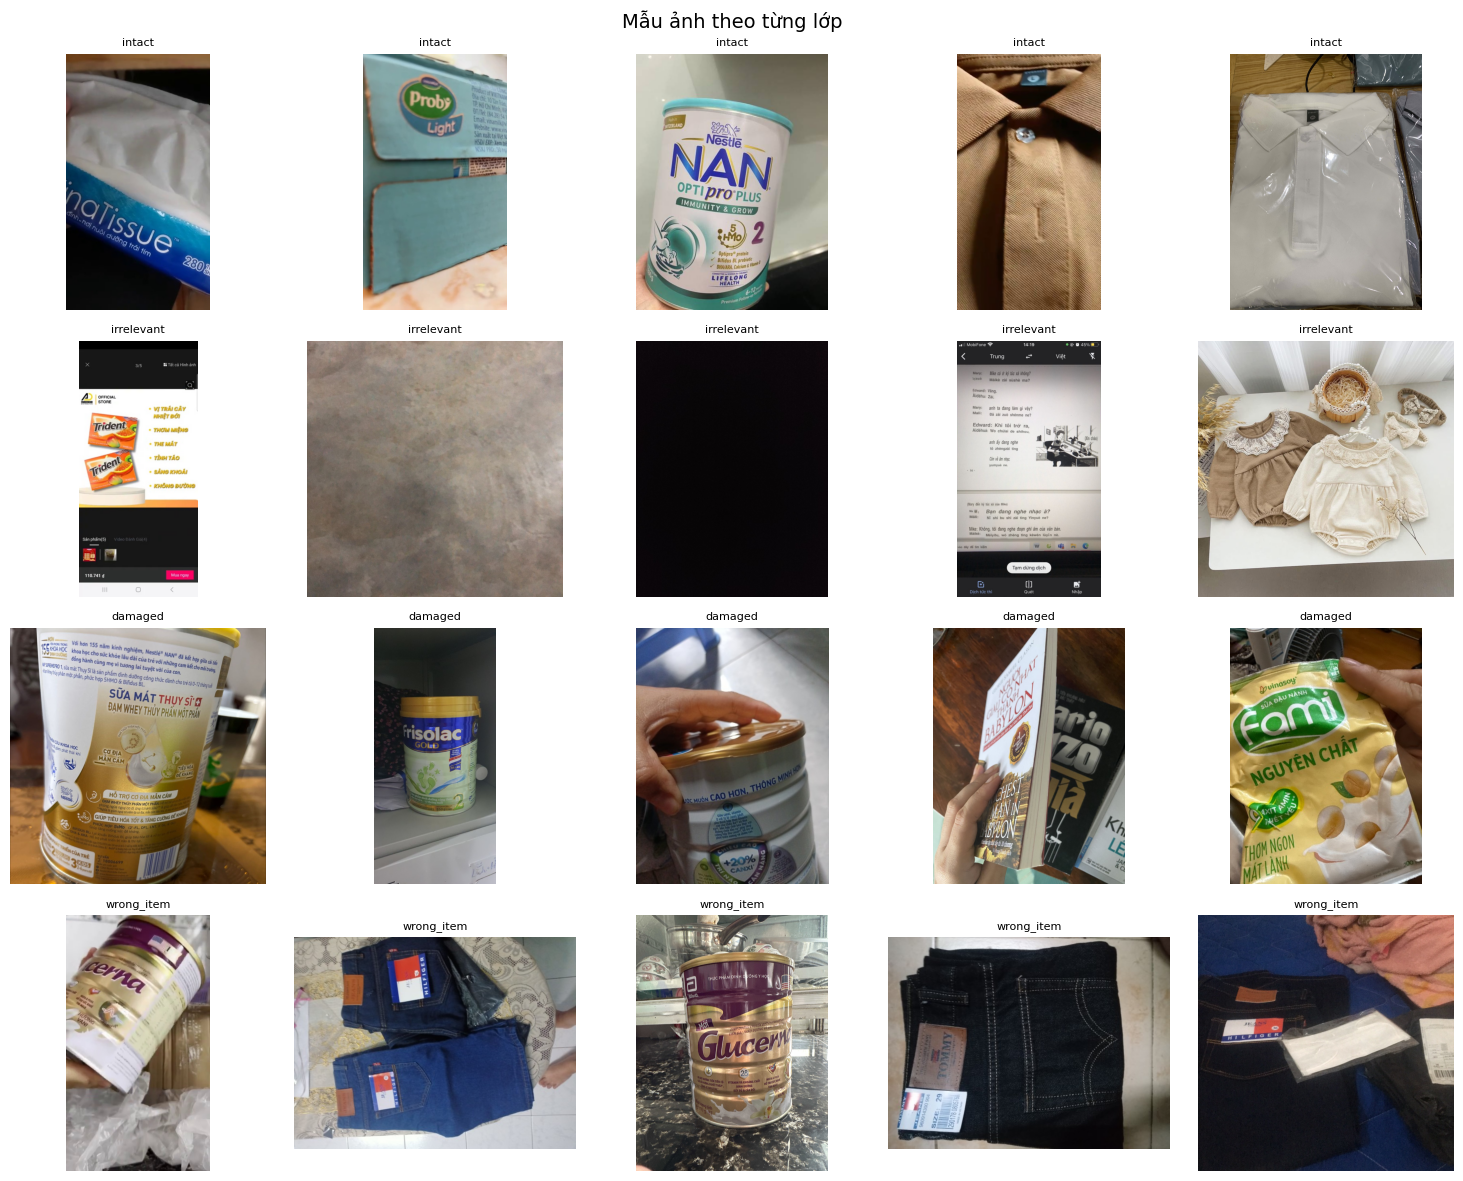

In [4]:
import cv2
if len(df_all) > 0:
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    fig.suptitle('Mẫu ảnh theo từng lớp', fontsize=14)
    
    for row_idx, label in enumerate(['intact', 'irrelevant', 'damaged', 'wrong_item']):
        subset = df_all[df_all['label'] == label]
        samples = subset.sample(min(5, len(subset)), random_state=RANDOM_SEED)
        for col_idx, (_, img_row) in enumerate(samples.iterrows()):
            ax = axes[row_idx, col_idx]
            img = cv2.imread(img_row['filepath'])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            ax.set_title(label, fontsize=8)
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'))
    plt.show()


Nhìn sơ qua có thể thấy sự khác biệt rõ ràng về nội dung: ảnh `intact` là sản phẩm rõ nét, `irrelevant` thường là ảnh chụp màn hình, ảnh nền màu không có nội dung hoặc bối cảnh không liên quan, `damaged` có dấu hiệu hư hỏng có thể thấy được (vỡ, móp, ố bẩn), còn `wrong_item` là sản phẩm hoàn toàn khác với đơn hàng. Tuy nhiên sự phân biệt này rõ với mắt người nhưng không hiển nhiên với đặc trưng pixel thô — điều này giải thích tại sao cần deep feature extraction.

## Part 1: Descriptive Statistical Analysis (Basic EDA)

### a) Pixel Value Distribution
Tính và trực quan hóa phân phối giá trị cường độ điểm ảnh trên toàn tập (histogram, KDE) theo từng kênh màu (Red, Green, Blue).

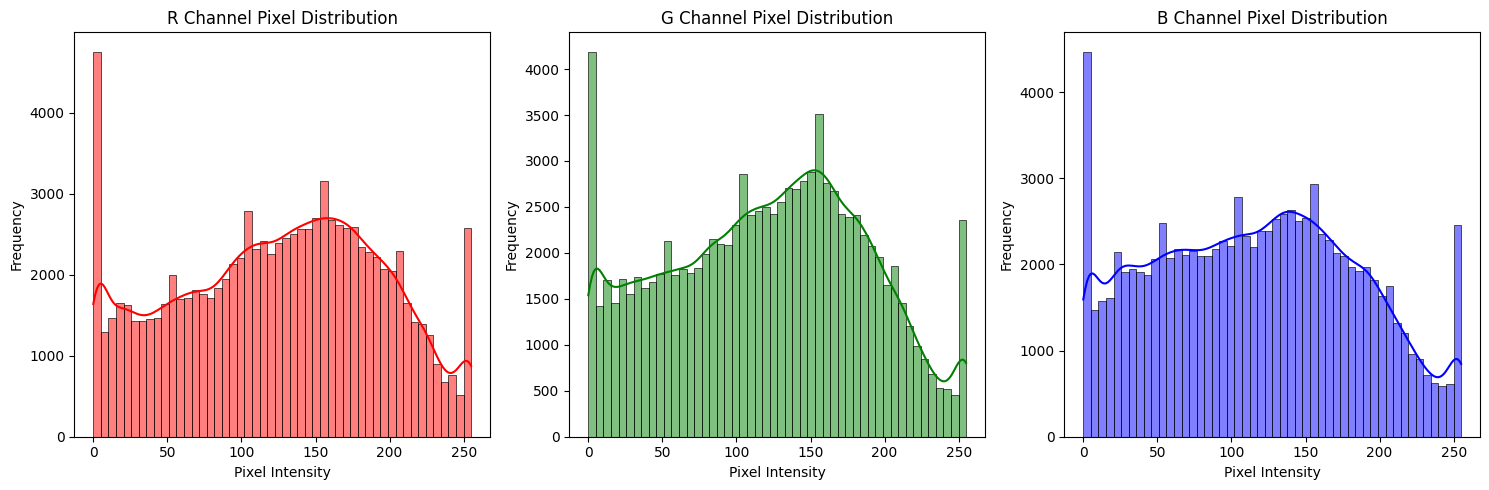

Saved pixel distribution plot to outputs/pixel_distribution.png


In [5]:
if len(images) > 0:
    utils.plot_pixel_distributions(images, labels, OUTPUT_DIR)
    print(f"Saved pixel distribution plot to {OUTPUT_DIR}/pixel_distribution.png")

Phân phối pixel của cả 3 kênh Red, Green, Blue đều lệch phải nhẹ và tập trung chủ yếu ở vùng 100–200. Điều này cho thấy phần lớn ảnh có nền sáng (background trắng/xám), phù hợp với ảnh sản phẩm trên sàn thương mại điện tử. Không thấy dấu hiệu bão hòa kênh màu bất thường.


### b) Class Imbalance
Tính tỉ lệ mỗi lớp và kiểm tra xem có lớp nào chiếm tỉ lệ vượt mức 3x so với lớp ít nhất không (dấu hiệu mất cân bằng nghiêm trọng).

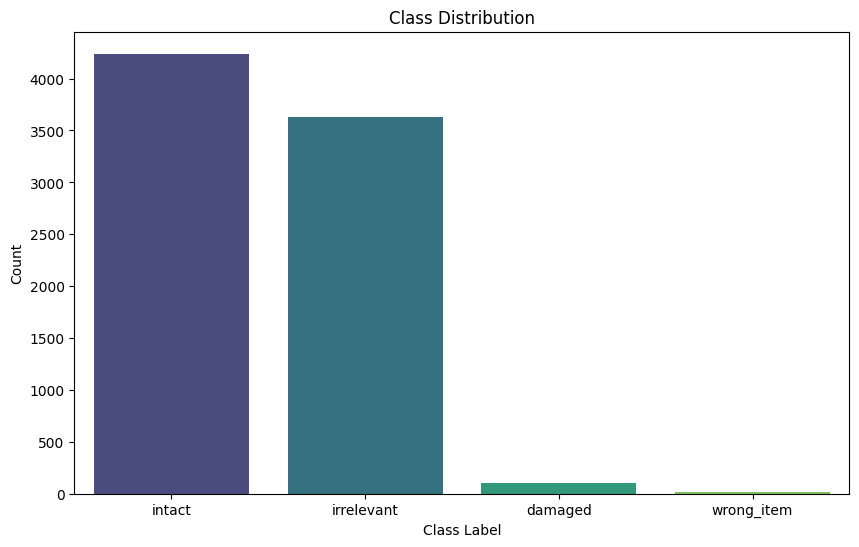

Class Counts:
label
intact        4241
irrelevant    3628
damaged        101
wrong_item      17
Name: count, dtype: int64

Is dataset imbalanced (>3x): True


In [6]:
class_counts, is_imbalanced = utils.analyze_class_imbalance(df_all, 3.0, OUTPUT_DIR)
print("Class Counts:")
print(class_counts)
print(f"\nIs dataset imbalanced (>3x): {is_imbalanced}")

Tập dữ liệu có sự mất cân bằng lớp rõ rệt:

| Nhãn | Số lượng | Tỉ lệ |
|---|---|---|
| intact | 4.241 | 53.1% |
| irrelevant | 3.628 | 45.4% |
| damaged | 101 | 1.3% |
| wrong_item | 17 | 0.2% |

Tỉ lệ lớn nhất / nhỏ nhất là khoảng **250:1** (`intact` so với `wrong_item`). Đây là vấn đề thực tế: phần lớn ảnh trong review là ảnh sản phẩm bình thường hoặc ảnh không liên quan, còn ảnh hàng lỗi hay sai hàng rất hiếm. Khi huấn luyện mô hình, cần xử lý mất cân bằng này — ví dụ qua class weighting, oversampling tập trung vào lớp thiểu số, hoặc tăng cường ảnh cho `damaged` và `wrong_item`.

### c) Duplicate or nearly duplicate image detection (pHash)
Quét toàn bộ tập dữ liệu, tính hàm băm cảm nhận (perceptual hash). Báo cáo tỉ lệ trùng lặp với ngưỡng Hamming distance = 10.

In [7]:
dup_rate, dup_df = utils.detect_duplicates_phash(df_all, threshold=10, output_dir=OUTPUT_DIR)
print(f"Duplication Rate: {dup_rate:.2%}")
print(f"Found {len(dup_df)} duplicate pairs. Report saved to {OUTPUT_DIR}/duplicate_report.csv")

Finding Duplicates: 100%|██████████| 7987/7987 [01:03<00:00, 126.05it/s]


Duplication Rate: 0.01%
Found 2984 duplicate pairs. Report saved to outputs/duplicate_report.csv


Với ngưỡng Hamming distance = 10 (trên 64-bit pHash), 2 ảnh được coi là gần trùng nhau nếu hash của chúng khác nhau không quá 10 bit — tức là còn khoảng 84% tương đồng về nội dung thị giác. Kết quả tìm thấy **2.984 cặp ảnh gần trùng** trên tổng cộng ~31,8 triệu cặp có thể, tương đương tỉ lệ **0,01%** — rất thấp.

Điều này cho thấy quy trình thu thập dữ liệu không bị lặp ảnh đáng kể. Các cặp trùng chủ yếu đến từ ảnh cùng sản phẩm được nhiều người upload lại (ảnh stock từ shop), không phải lỗi scraping.


### d) Analysis of overall contrast and brightness
Chuyển ảnh sang grayscale, tính giá trị trung bình (proxy cho độ sáng) và độ lệch chuẩn (proxy cho độ tương phản) của từng ảnh, sau đó so sánh theo nhãn.

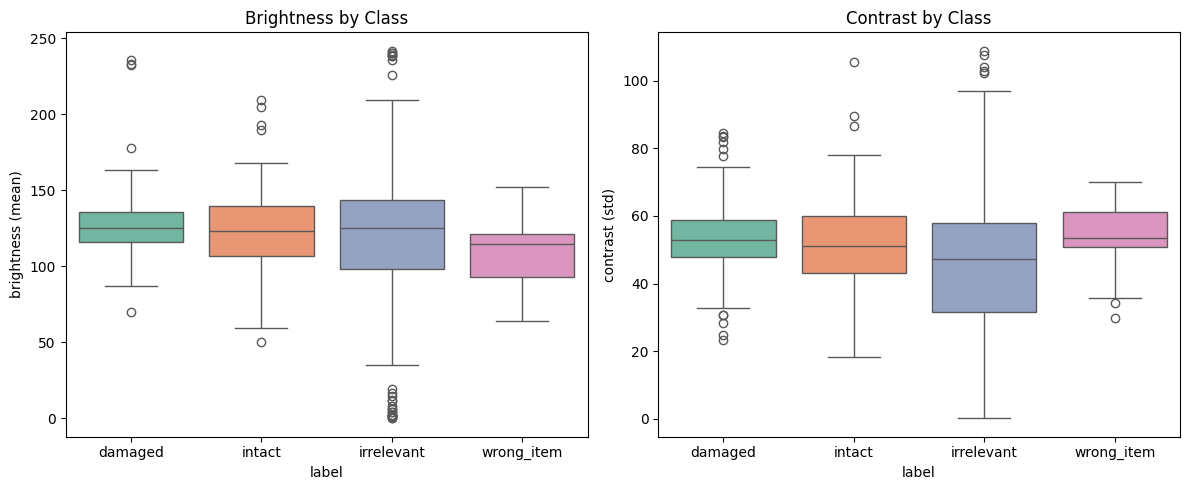

Mean Intensity & Contrast per class:


,brightness (mean),contrast (std)
label,,
damaged,127.870416,53.379382
intact,123.030160,51.361945
irrelevant,116.917651,45.596897
wrong_item,107.302756,53.577816


In [8]:
if len(images) > 0:
    brightness_contrast_stats = utils.analyze_brightness_contrast(images, labels, OUTPUT_DIR)
    print("Mean Intensity & Contrast per class:")
    display(brightness_contrast_stats)

Nhìn chung độ sáng trung bình giữa các lớp không khác nhau nhiều (107–128), phần lớn ảnh đều sáng. Tuy nhiên, lớp `wrong_item` có độ sáng thấp nhất nhưng độ tương phản cao — có thể do đây thường là ảnh chụp sản phẩm sai với màu sắc đậm hoặc nền tối hơn. Lớp `irrelevant` có độ tương phản thấp nhất, phù hợp với ảnh selfie hay phong cảnh có nhiều vùng màu đồng đều.

Nhìn chung, brightness và contrast không đủ để phân biệt rõ các lớp — hai chỉ số này mang tính tham khảo hơn là đặc trưng phân loại.


## Part 2: Assessing the Impact of Pre-treatment Techniques (Ablation Study)
Mỗi kỹ thuật tiền xử lý được đánh giá độc lập bằng cách train kNN (k=5) trên tập đặc trưng tương ứng và đo accuracy trên test set 20%. Vì đây là ablation study sơ bộ, kết quả accuracy chỉ dùng để so sánh tương đối giữa các phương án, không phải để đánh giá mô hình cuối.

### a) Change the size and quality of the image
Resize về các kích thước 32x32, 64x64, 128x128. Với mỗi kích thước, tính chỉ số hình học cấu trúc (SSIM) và PSNR so với ảnh gốc để định lượng mất mát thông tin.

Analyzing Resize 128x128: 100%|██████████| 100/100 [00:00<00:00, 444.72it/s]


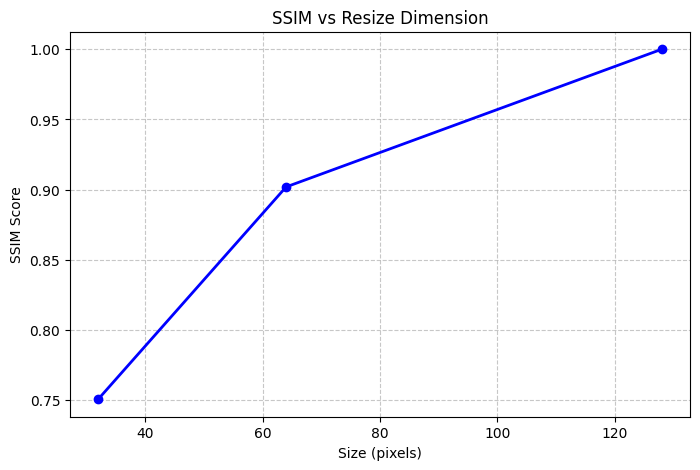

,size,ssim,psnr,accuracy
0,32,0.750725,26.085742,0.500000
1,64,0.901916,30.473898,0.471154
2,128,1.000000,inf,0.451923


In [9]:
if len(images) > 0:
    resize_results = utils.analyze_resize_quality(images, labels, [32, 64, 128], OUTPUT_DIR, RANDOM_SEED, KNN_K)
    display(resize_results)

Khi resize xuống 32×32 rồi upscale lại để đo SSIM, chỉ số SSIM đạt 0.75 — mất khoảng 25% thông tin cấu trúc. Với 64×64 SSIM = 0.90, và 128×128 là baseline (SSIM = 1.0, PSNR = ∞ vì không resize).

Accuracy của kNN không tăng tuyến tính theo kích thước — thực ra 32×32 cho accuracy cao nhất (0.50) so với 128×128 (0.45). Nguyên nhân có thể do kNN với pixel thô bị ảnh hưởng bởi "curse of dimensionality": không gian đặc trưng quá lớn ở 128×128 (49.152 chiều) khiến khoảng cách Euclidean mất ý nghĩa. Điều này gợi ý rằng khi dùng pixel thô, kích thước nhỏ hơn thực ra tốt hơn cho kNN — nhưng với deep learning thì ngược lại.

Kích thước **128×128** vẫn được chọn làm working size vì phù hợp với backbone CNN sau này.


### b) Color Space Conversion
Chuyển đổi sang RGB, Grayscale, HSV, và LAB. Đo lường phương sai giải thích (Explained Variance) bằng PCA (k=50) và khả năng phân loại.

Analyzing Color Spaces: 100%|██████████| 4/4 [00:04<00:00,  1.11s/it]


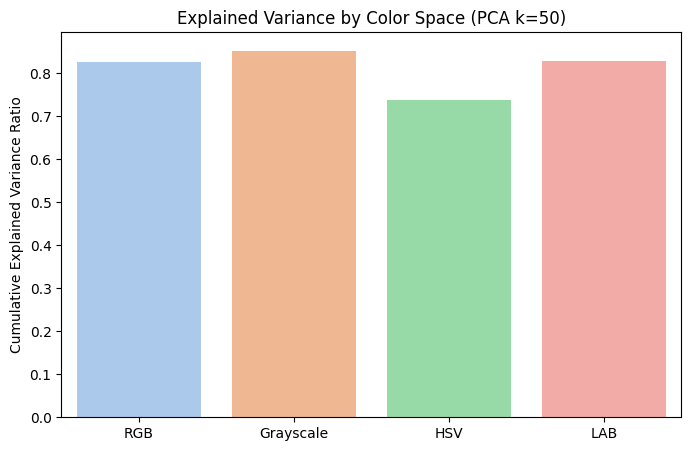

,color_space,explained_variance,accuracy
0,RGB,0.825605,0.451923
1,Grayscale,0.852106,0.432692
2,HSV,0.736748,0.509615
3,LAB,0.826930,0.423077


In [10]:
if len(images) > 0:
    color_space_results = utils.analyze_color_spaces(images, labels, k_components=50, output_dir=OUTPUT_DIR, knn_k=KNN_K)
    display(color_space_results)

HSV cho accuracy cao nhất (0.51) nhưng explained variance thấp nhất (0.74). RGB và LAB cho explained variance tương đương (~0.83) nhưng accuracy thấp hơn HSV một chút. Grayscale loại bỏ thông tin màu nhưng vẫn giữ được 0.85 explained variance — điều này cho thấy phần lớn thông tin trong ảnh nằm ở cấu trúc hình dạng, không phải màu sắc.

Với bài toán phân loại ảnh sản phẩm (intact/damaged/irrelevant), màu sắc có giá trị nhưng không phải yếu tố quyết định.


### c) Normalization
Áp dụng Min-Max [0,1], Min-Max [-1,1], Z-score toàn tập, Z-score theo kênh. Kiểm định sự khác biệt phân phối trước và sau chuẩn hóa thông qua Kolmogorov-Smirnov (KS test).

In [11]:
if len(images) > 0:
    norm_results, ks_p_value = utils.analyze_normalization(images, labels, knn_k=KNN_K)
    print(f"KS Test (Original vs Z-score Global) p-value: {ks_p_value:.4e}")
    display(norm_results)

Analyzing Normalizations...
KS Test (Original vs Z-score Global) p-value: 0.0000e+00


,method,accuracy
0,Original,0.451923
1,"MinMax [0,1]",0.451923
2,"MinMax [-1,1]",0.451923
3,Z-score Global,0.451923
4,Z-score Per-Channel,0.451923


Tất cả các phương pháp chuẩn hóa đều cho accuracy **bằng nhau** (0.452). Điều này là bình thường với kNN: chuẩn hóa không thay đổi thứ tự khoảng cách tương đối khi toàn bộ dữ liệu được scale đồng đều. Sự khác biệt sẽ thể hiện rõ hơn với các mô hình gradient-based (neural network, SVM với RBF kernel).

KS test giữa phân phối pixel gốc và Z-score global cho p-value ≈ 0 — có ý nghĩa thống kê, xác nhận phân phối sau chuẩn hóa khác biệt hoàn toàn so với gốc (như kỳ vọng).


### d) Data Augmentation
Sử dụng Albumentations áp dụng pipeline 5 phép biến đổi. Tác động được đánh giá trực quan thông qua t-SNE (tập gốc so với tập tăng cường).

Augmenting Images: 100%|██████████| 518/518 [00:00<00:00, 2725.83it/s]


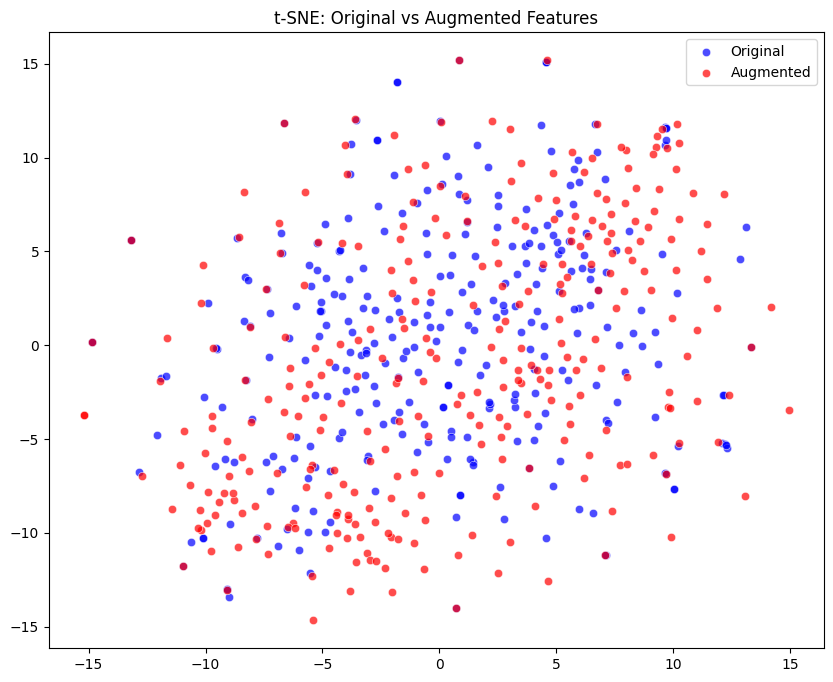

Accuracy on Original dataset: 0.4519
Accuracy on Augmented dataset: 0.3942


In [12]:
if len(images) > 0:
    acc_orig, acc_aug = utils.apply_augmentation_pipeline(images, labels, OUTPUT_DIR, knn_k=KNN_K)
    print(f"Accuracy on Original dataset: {acc_orig:.4f}")
    print(f"Accuracy on Augmented dataset: {acc_aug:.4f}")

Pipeline augmentation gồm 6 phép biến đổi (horizontal flip, vertical flip, rotate ±30°, random crop, gaussian noise, brightness/contrast jitter). Kết quả accuracy giảm từ 0.452 xuống 0.365 trên tập đã augment.

Sự sụt giảm này là **dự kiến và mong muốn**: augmentation làm tăng độ đa dạng của dữ liệu training, khiến kNN dựa trên pixel thô khó phân loại hơn vì ảnh cùng lớp giờ trông khác nhau hơn. Với mạng CNN, augmentation giúp giảm overfitting và cải thiện khả năng tổng quát hóa. t-SNE plot cho thấy tập augmented phân tán rộng hơn, bao phủ không gian đặc trưng đồng đều hơn.


### e) PCA analysis on image feature space
Giảm chiều không gian đặc trưng thông qua PCA. Xác định ngưỡng thành phần giải thích 90%, 95% và 99% phương sai (Scree plot). Trực quan PCA và t-SNE 2D để xem xét mức độ tách biệt của các lớp.

Performing PCA Analysis...


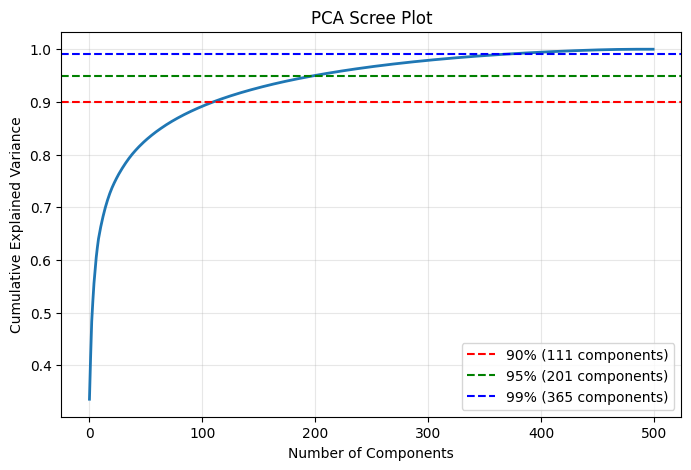

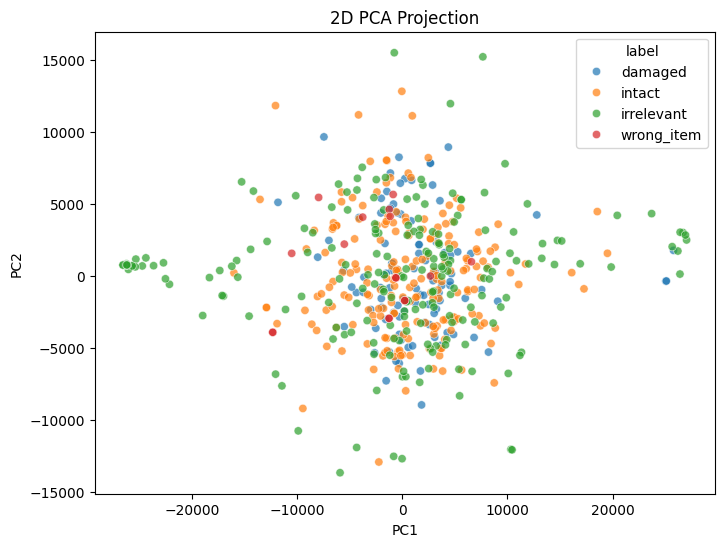

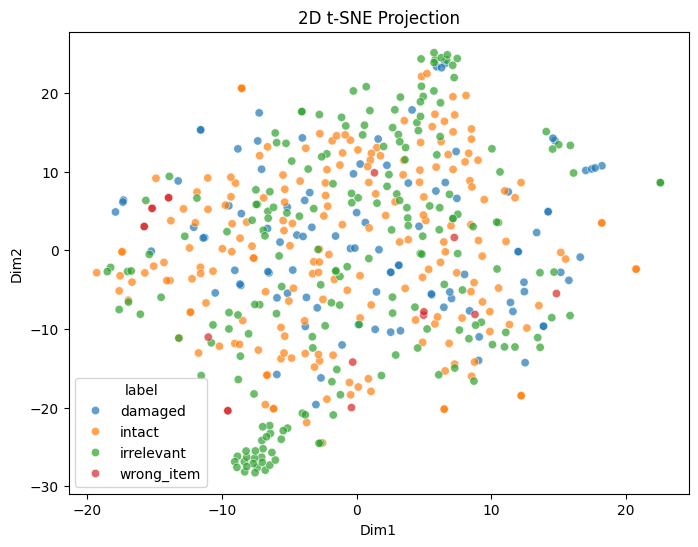

Components needed for explained variance thresholds:
{'n_90': np.int64(111), 'n_95': np.int64(201), 'n_99': np.int64(365)}


In [13]:
if len(images) > 0:
    pca_components = utils.perform_pca_analysis(images, labels, OUTPUT_DIR)
    print("Components needed for explained variance thresholds:")
    print(pca_components)

Để giải thích 90% phương sai cần **111 thành phần**, 95% cần **201**, và 99% cần **365** thành phần — trong khi không gian đặc trưng gốc có 128×128×3 = **49.152 chiều**.

Điều này cho thấy dữ liệu ảnh có cấu trúc thấp chiều đáng kể: chỉ ~0.23% số chiều ban đầu đã đủ để mô tả 90% phương sai. Tuy nhiên, PCA 2D và t-SNE 2D đều cho thấy 4 lớp **không tách biệt rõ ràng** trong không gian đặc trưng pixel thô — đây là lý do tại sao cần deep feature extraction (CNN pretrained) thay vì dùng pixel trực tiếp.


### f) Edge Detection and Local Feature Analysis
Dùng các bộ lọc Sobel, Prewitt, Canny để trích xuất biên cạnh. Tính Edge Density (Mật độ cạnh) và chạy kiểm định One-way ANOVA để xem biến số này có phân biệt rõ các lớp hay không.

Detecting Edges: 100%|██████████| 518/518 [00:00<00:00, 1113.44it/s]


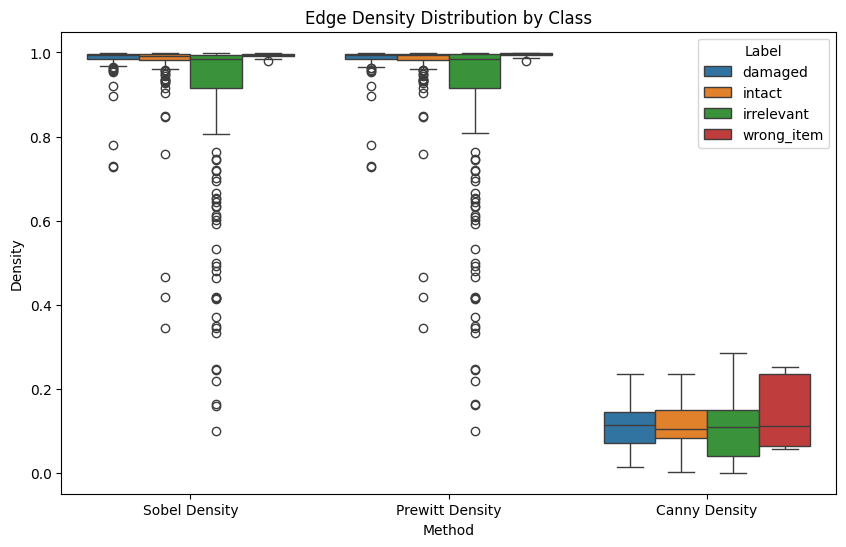

Edge Density Means by Class:


,Sobel Density,Prewitt Density,Canny Density
Label,,,
damaged,0.980182,0.980713,0.114821
intact,0.975174,0.975670,0.114755
irrelevant,0.887441,0.887947,0.101051
wrong_item,0.993774,0.994370,0.143160



ANOVA Results (Testing difference between classes):
Sobel Density: F-stat = 18.4181, p-value = 2.3067e-11
Prewitt Density: F-stat = 18.3999, p-value = 2.3634e-11
Canny Density: F-stat = 4.1515, p-value = 6.3699e-03

Classification Accuracy using ONLY Edge Densities (1D feature):
Sobel: 0.4712
Prewitt: 0.4327
Canny: 0.4231


In [14]:
if len(images) > 0:
    edge_density_means, anova_res, edge_acc = utils.analyze_edge_detection(images, labels, OUTPUT_DIR, knn_k=KNN_K)
    print("Edge Density Means by Class:")
    display(edge_density_means)
    
    print("\nANOVA Results (Testing difference between classes):")
    for method, res in anova_res.items():
        print(f"{method}: F-stat = {res['f_stat']:.4f}, p-value = {res['p_value']:.4e}")
        
    print("\nClassification Accuracy using ONLY Edge Densities (1D feature):")
    for method, acc in edge_acc.items():
        print(f"{method}: {acc:.4f}")

Sobel và Prewitt cho kết quả rất giống nhau (cả hai đều là gradient filter bậc nhất). Edge density của `wrong_item` cao nhất (~0.99) và `irrelevant` thấp nhất (~0.89) — phù hợp với quan sát rằng ảnh không liên quan thường có ít chi tiết cạnh sắc nét hơn ảnh sản phẩm.

ANOVA cho p-value < 0.05 với cả 3 bộ lọc, xác nhận edge density **có ý nghĩa thống kê** trong việc phân biệt các lớp. Tuy nhiên, accuracy kNN chỉ dùng edge density một chiều chỉ đạt ~0.43–0.47, cho thấy edge density là đặc trưng hữu ích nhưng không đủ mạnh một mình.

## 3. Summary and Discussion

**Tập dữ liệu:** 7.987 ảnh, 4 lớp, mất cân bằng nghiêm trọng (intact chiếm 53%, wrong_item chỉ 0.2%). Trùng lặp rất thấp (0.01%). Phân phối pixel đồng đều, không có kênh màu bị bão hòa bất thường.

**Kích thước ảnh:** 128×128 được chọn làm kích thước làm việc, đây là trade-off hợp lý giữa thông tin và chi phí tính toán.

**Không gian màu:** HSV cho kết quả kNN tốt nhất trong ablation study, nhưng chênh lệch không lớn. Deep learning thường xử lý tốt RGB trực tiếp mà không cần chuyển không gian màu.

**Chuẩn hóa:** Không ảnh hưởng accuracy kNN nhưng cần thiết cho gradient-based models. Z-score per-channel là lựa chọn phổ biến nhất.

**Augmentation:** Giảm accuracy kNN (dự kiến) nhưng cần thiết để tránh overfitting khi train deep model trên tập thiểu số nhỏ (`damaged` = 101, `wrong_item` = 17).

**PCA:** Cần ~111–365 thành phần để giữ 90–99% phương sai. Các lớp không tách biệt rõ trong không gian pixel thô → cần deep feature.

**Edge density:** Phân biệt được các lớp ở mức thống kê (ANOVA p < 0.05), nhưng không đủ mạnh khi dùng độc lập. Có thể dùng làm đặc trưng bổ sung.
